# 05 Basket CDS Pricing

## Credit Risk Basket CDS Pricing

### Objective

The objective of this notebook is to estimate the fair spread of a Basket Credit Default Swap (Basket CDS) using Monte Carlo simulation.

The correlated uniform variables generated by the Gaussian Copula model are transformed into default times. These simulated default times are then used to estimate expected losses for first-to-default through fifth-to-default Basket CDS contracts.

## Step 1 Import Required Libraries

This notebook uses:

- NumPy for numerical calculations
- pandas for data handling
- scipy.stats for probability functions

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## Step 2 Load Model Inputs

The Basket CDS pricing model requires:

- Hazard rates
- Correlation matrix
- Recovery rate

In [14]:
hazard_rates = np.array([
    0.0100,
    0.0125,
    0.0142,
    0.0117,
    0.0133
])

recovery = 0.40

In [15]:
prices = pd.read_csv("../Data/bank_prices.csv", index_col=0)

returns = prices.pct_change().dropna()

corr = returns.corr()

## Step 3 Simulate Correlated Market Scenarios

The Gaussian Copula model is used to generate correlated uniform random variables representing joint default scenarios.

In [16]:
n_sim = 10000

Z = np.random.multivariate_normal(
    np.zeros(5),
    corr,
    n_sim
)

U = norm.cdf(Z)

## Step 4 Estimate Default Times

The simulated uniform variables are transformed into default times using the inverse survival function.

Smaller uniform values correspond to earlier default events.

In [17]:
default_times = -np.log(U) / hazard_rates

default_times[:5]

array([[274.21178199, 122.07275609, 286.60745741, 212.04389797,
        227.42545838],
       [ 23.73109376,  15.95653441,  10.19021672, 121.10297438,
         19.28226977],
       [ 70.67042776, 100.0043909 ,  84.91470159, 137.01094703,
        205.32916854],
       [ 95.35001716,  46.59911674,  17.63276928,  72.47836273,
         58.66236876],
       [224.14534559, 110.02698322, 206.96703468, 167.48138012,
        193.30983449]])

## Step 5 Rank Default Events

Within each simulation, default times are sorted from earliest to latest.

This allows pricing of first-to-default, second-to-default, and higher-order Basket CDS contracts.

In [18]:
ranked_defaults = np.sort(default_times, axis=1)

ranked_defaults[:5]

array([[122.07275609, 212.04389797, 227.42545838, 274.21178199,
        286.60745741],
       [ 10.19021672,  15.95653441,  19.28226977,  23.73109376,
        121.10297438],
       [ 70.67042776,  84.91470159, 100.0043909 , 137.01094703,
        205.32916854],
       [ 17.63276928,  46.59911674,  58.66236876,  72.47836273,
         95.35001716],
       [110.02698322, 167.48138012, 193.30983449, 206.96703468,
        224.14534559]])

## Step 6 Calculate Expected Default Times

Average default times are calculated across all Monte Carlo simulations for each default order.

In [19]:
expected_defaults = ranked_defaults.mean(axis=0)

expected_defaults

array([ 39.88421827,  58.30732686,  77.07279863,  99.82355203,
       137.81609273])

## Step 7 Estimate Basket CDS Spread

A simplified pricing approximation is used in this project.

The Basket CDS spread is estimated from the expected loss:

Spread = Hazard Rate × (1 − Recovery Rate)

This simplified framework demonstrates the pricing workflow before extending to a full premium-leg and protection-leg valuation.

In [20]:
basket_spread = hazard_rates * (1 - recovery)

pricing = pd.DataFrame({
    "Order": [
        "1st-to-Default",
        "2nd-to-Default",
        "3rd-to-Default",
        "4th-to-Default",
        "5th-to-Default"
    ],
    "Expected Default Time": expected_defaults,
    "Approx Spread": basket_spread
})

pricing

,Order,Expected Default Time,Approx Spread
0,1st-to-Default,39.884218,0.00600
1,2nd-to-Default,58.307327,0.00750
2,3rd-to-Default,77.072799,0.00852
3,4th-to-Default,99.823552,0.00702
4,5th-to-Default,137.816093,0.00798


In [21]:
pricing["Approx Spread (bps)"] = pricing["Approx Spread"] * 10000

pricing["Expected Default Time"] = (
    pricing["Expected Default Time"].round(2)
)

pricing["Approx Spread (bps)"] = (
    pricing["Approx Spread (bps)"].round(2)
)

pricing

,Order,Expected Default Time,Approx Spread,Approx Spread (bps)
0,1st-to-Default,39.88,0.00600,60.0
1,2nd-to-Default,58.31,0.00750,75.0
2,3rd-to-Default,77.07,0.00852,85.2
3,4th-to-Default,99.82,0.00702,70.2
4,5th-to-Default,137.82,0.00798,79.8


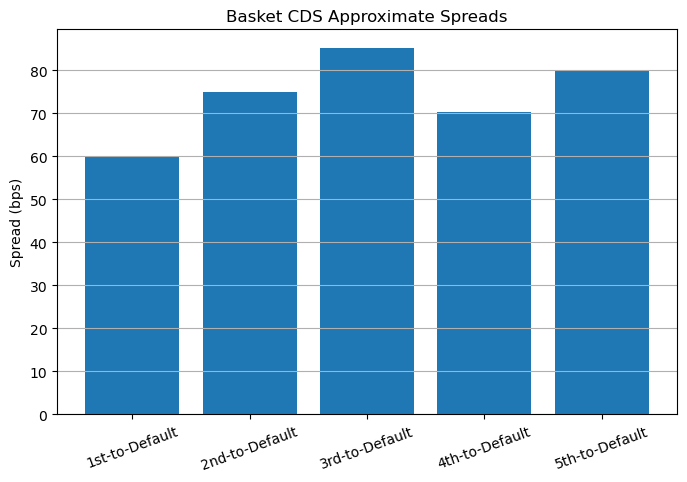

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    pricing["Order"],
    pricing["Approx Spread (bps)"]
)

plt.title("Basket CDS Approximate Spreads")

plt.ylabel("Spread (bps)")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

# Business Interpretation

The Basket CDS premium depends on both individual default risk and the dependence structure among the reference entities.

Earlier default events generally result in higher protection values because the protection buyer receives compensation sooner.

The Gaussian Copula model captures the possibility of multiple firms experiencing financial distress during the same market conditions, making correlation a key driver of Basket CDS valuation.

# Summary

In this notebook we:

- Generated correlated market scenarios
- Simulated default times
- Ranked default events
- Estimated expected default times
- Calculated approximate Basket CDS spreads

The pricing results provide the baseline model that will be stress-tested in the sensitivity analysis.